
### Reference
* https://github.com/sinaptik-ai/pandas-ai/tree/main
* https://wikidocs.net/226630
* https://github.com/elise-chin/poetry-and-colab/blob/main/Using_python_poetry_in_Google_Colab.ipynb

# Setting
- poetry install
- install pandasai

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
%cd /content/gdrive/MyDrive/

/content/gdrive/MyDrive


In [ ]:
!rm -rf test-poetry
!mkdir test-poetry
%cd test-poetry

/content/gdrive/MyDrive/test-poetry


In [ ]:
!pip install poetry #install poetry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.8/544.8 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.7/78.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 979.7/979.7 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.8/453.8 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 78.3 MB/s eta 0:00:00
  Attempting uninstall: keyring
    Found existing installation: keyring 23.5.0
    Uninstalling keyring-23.5.0:
      Successfully uninstalled keyring-23.5.0


In [ ]:
# 가상 환경 생성하지 않음
# 가상환경 생성 코드 : !poetry config virtualenvs.in-project true
!poetry config virtualenvs.in-project false

In [ ]:
!poetry init


This command will guide you through creating your pyproject.toml config.

Package name [content]:  test-poetry
Version [0.1.0]:  0.1.0
Description []:  
Author [None, n to skip]:  n
License []:  n
Compatible Python versions [>=3.11]:  

Would you like to define your main dependencies interactively? (yes/no) [yes] no
Would you like to define your development dependencies interactively? (yes/no) [yes] no
Generated file

[project]
name = "test-poetry"
version = "0.1.0"
description = ""
authors = [
    {name = "Your Name",email = "you@example.com"}
]
license = {text = "n"}
readme = "README.md"
requires-python = ">=3.11"
dependencies = [
]


[build-system]
requires = ["poetry-core>=2.0.0,<3.0.0"]
build-backend = "poetry.core.masonry.api"


Do you confirm generation? (yes/no) [yes] yes


In [ ]:
!poetry add pandasai #pandasai 설치

Creating virtualenv test-poetry-6R8_UNrD-py3.11 in /root/.cache/pypoetry/virtualenvs
Using version ^2.4.2 for pandasai

Updating dependencies
Resolving dependencies... (5.6s)

Package operations: 63 installs, 0 updates, 0 removals

  - Installing certifi (2024.12.14): Pending...
  - Installing h11 (0.14.0): Pending...
  - Installing idna (3.10): Pending...
  - Installing nvidia-nvjitlink-cu12 (12.8.61): Pending...
  - Installing sniffio (1.3.1): Pending...
  - Installing typing-extensions (4.12.2): Pending...
  - Installing h11 (0.14.0): Pending...
  - Installing idna (3.10): Pending...
  - Installing nvidia-nvjitlink-cu12 (12.8.61): Pending...
  - Installing sniffio (1.3.1): Pending...
  - Installing typing-extensions (4.12.2): Pending...
  - Installing certifi (2024.12.14): Downloading... 0%
  - Installing h11 (0.14.0): Pending...
  - Installing idna (3.10): Pending...
  - Installing nvidia-nvjitlink-cu12 (12.8.61): Pending...
  - Installing sniffio (1.3.1): Pending...
  - Installing

In [ ]:
import pandas as pd
import numpy as np
import pandasai as pdai
from pandasai.llm.openai import OpenAI
from pandasai import SmartDataframe

# Using LLM with Data
* API key 발급 : https://getpanda.ai/
* 카드 정보 입력 및 결제 필요(세금 포함 최소 5.5$)

In [ ]:
api_key = "your_api_key"
llm = OpenAI(api_token = api_key)

In [ ]:
# Print LLM configuration to verify setup
print(f"LLM Type: {type(llm)}")
print(f"LLM Configuration:")
print(f"- Model: {llm.model}")  # Changed from model_name to model
print(f"- Temperature: {llm.temperature}")
print(f"- Max Tokens: {llm.max_tokens}")

LLM Type: <class 'pandasai.llm.openai.OpenAI'>
LLM Configuration:
- Model: gpt-4o-mini
- Temperature: 0
- Max Tokens: 1000


In [ ]:
df = pd.DataFrame({
    "country": ["United States", "United Kingdom", "France", "Germany", "Italy", "Spain", "Canada", "Australia", "Japan", "China"],
    "gdp": [19294482071552, 2891615567872, 2411255037952, 3435817336832, 1745433788416, 1181205135360, 1607402389504, 1490967855104, 4380756541440, 14631844184064],
    "happiness_index": [6.94, 7.16, 6.66, 7.07, 6.38, 6.4, 7.23, 7.22, 5.87, 5.12]
})

In [ ]:
df = SmartDataframe(df, config={"llm": llm})
df.chat('Which are the 5 happiest countries?')

{'type': 'dataframe', 'value':           country             gdp  happiness_index
6          Canada   1607402389504             7.23
7       Australia   1490967855104             7.22
1  United Kingdom   2891615567872             7.16
3         Germany   3435817336832             7.07
0   United States  19294482071552             6.94}


,country,gdp,happiness_index
6,Canada,1607402389504,7.23
7,Australia,1490967855104,7.22
1,United Kingdom,2891615567872,7.16
3,Germany,3435817336832,7.07
0,United States,19294482071552,6.94


ERROR:pandasai.helpers.logger:Failed with error: Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pandasai/pipelines/chat/code_execution.py", line 85, in execute
    result = self.execute_code(code_to_run, code_context)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pandasai/pipelines/chat/code_execution.py", line 174, in execute_code
    exec(code, environment)
  File "<string>", line 5, in <module>
  File "/usr/local/lib/python3.11/dist-packages/pandasai/safe_libs/restricted_matplotlib.py", line 75, in __getattr__
    raise AttributeError(f"'{name}' is not allowed in RestrictedMatplotlib")
AttributeError: 'cm' is not allowed in RestrictedMatplotlib

ERROR:pandasai.helpers.logger:Failed with error: Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pandasai/pipelines/chat/code_execution.py", line 85, in execute
    result = self.execute_code(code_to_run, code_co

'/content/exports/charts/temp_chart.png'

<Figure size 1000x600 with 0 Axes>

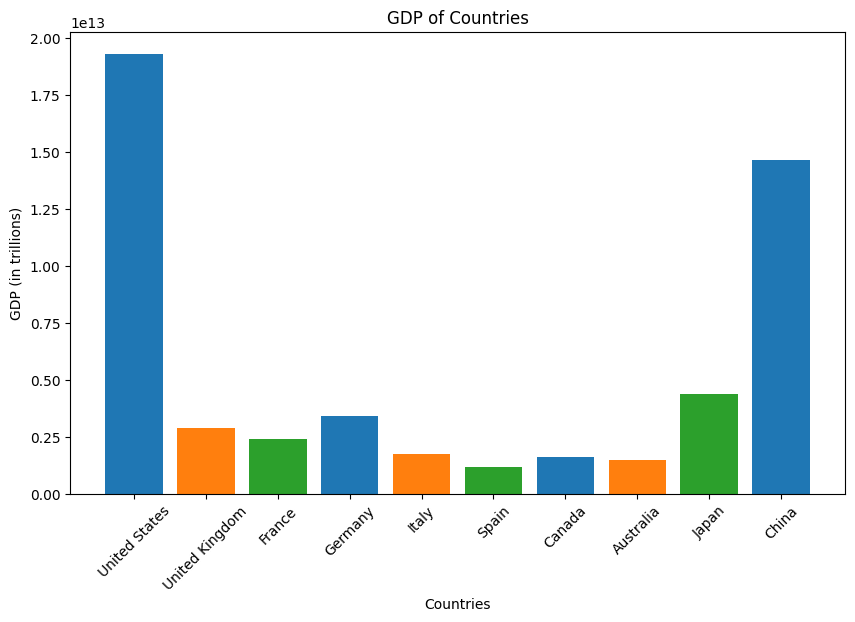

In [ ]:
df.chat(
    "Plot the histogram of countries showing for each one the gdp. Use different colors for each bar",
)

ERROR:pandasai.helpers.logger:Failed with error: Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pandasai/pipelines/chat/code_execution.py", line 85, in execute
    result = self.execute_code(code_to_run, code_context)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pandasai/pipelines/chat/code_execution.py", line 174, in execute_code
    exec(code, environment)
  File "<string>", line 5, in <module>
  File "/usr/local/lib/python3.11/dist-packages/pandasai/safe_libs/restricted_matplotlib.py", line 75, in __getattr__
    raise AttributeError(f"'{name}' is not allowed in RestrictedMatplotlib")
AttributeError: 'cm' is not allowed in RestrictedMatplotlib

ERROR:pandasai.helpers.logger:Failed with error: Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pandasai/pipelines/chat/code_execution.py", line 85, in execute
    result = self.execute_code(code_to_run, code_co

,country,gdp,happiness_index
0,United States,19294482071552,6.94
9,China,14631844184064,5.12
8,Japan,4380756541440,5.87
3,Germany,3435817336832,7.07
1,United Kingdom,2891615567872,7.16
2,France,2411255037952,6.66
4,Italy,1745433788416,6.38
6,Canada,1607402389504,7.23
7,Australia,1490967855104,7.22
5,Spain,1181205135360,6.40


<Figure size 1000x600 with 0 Axes>

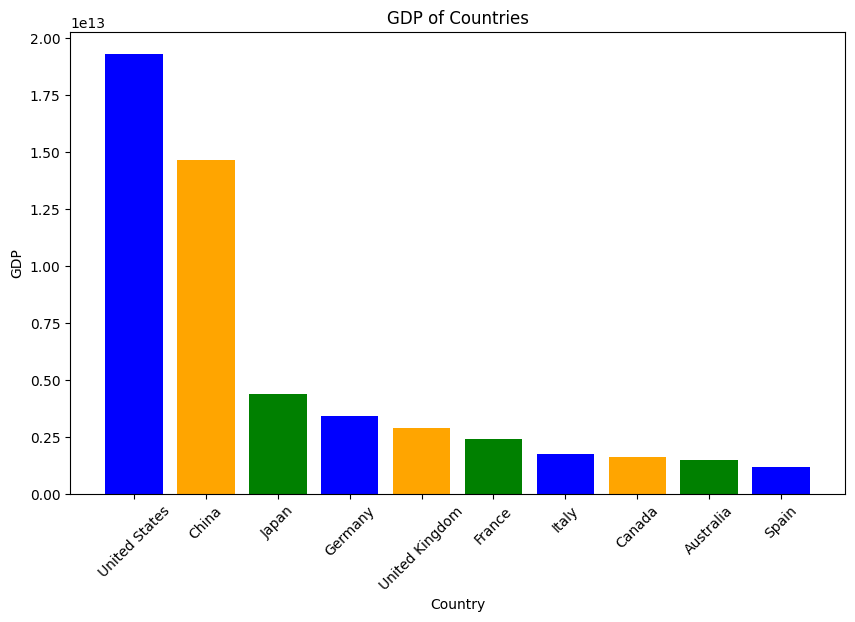

In [ ]:
df.chat("order the above chart by gdp")